# ***Tiền xử lý dữ liệu***

In [1]:
import pandas as pd
import re
import numpy as np

# Cấu hình hiển thị full text để dễ kiểm tra
pd.set_option('display.max_colwidth', None)

# Load file dữ liệu (Thay path của bạn vào)
# df_qa = pd.read_csv('path_to_your_qa_file.csv')

# Dữ liệu mẫu demo (dựa trên ví dụ bạn cung cấp)
data_demo = {
    'id': [1],
    'question': ['Mối quan hệ biện chứng giữa cái tất yếu và cái ngẫu nhiên?'],
    'ground_truth': ['Cái tất yếu và ngẫu nhiên liên hệ mật thiết...'],
    'edurag_ans': ["""
-   **sự thống nhất giữa cái tất yếu và cái ngẫu nhiên:**
    -   cái tất yếu luôn biểu hiện sự tồn tại của mình thông qua vô số cái ngẫu nhiên. cái ngẫu nhiên là hình thức biểu hiện của cái tất yếu, đồng thời bổ sung cho cái tất yếu [triethoc_chunk_00193].
    -   ví dụ, sự xuất hiện của những nhân vật kiệt xuất trong lịch sử là tất yếu do nhu cầu của xã hội, nhưng nhân vật cụ thể nào xuất hiện thì lại là ngẫu nhiên, có thể thay thế bằng người khác nếu họ không xuất hiện [triethoc_chunk_00193].

-   **sự chuyển hóa giữa cái tất yếu và cái ngẫu nhiên:**
    -   trong những điều kiện nhất định, cái tất yếu có thể chuyển hóa thành cái ngẫu nhiên và ngược lại. ranh giới giữa chúng chỉ có ý nghĩa tương đối [triethoc_chunk_00194].

**tóm lại,** cái tất yếu và cái ngẫu nhiên là hai mặt không thể tách rời."""],
    'baseline_ans': ['Cái tất yếu và cái ngẫu nhiên có mối quan hệ biện chứng... (văn bản thường)'],
    'edurag_time': [15.5],
    'baseline_time': [5.2]
}

df_qa = pd.DataFrame(pd.read_csv('result/QA_result.csv'))

print("Dữ liệu gốc trước khi xử lý:")
display(df_qa[['edurag_ans']].head(1))

Dữ liệu gốc trước khi xử lý:


,edurag_ans
0,"quan điểm ""vô thường"" trong triết học phật giáo chỉ ra rằng vạn vật luôn biến đổi không ngừng theo chu trình sinh - trụ - dị - diệt. điều này có nghĩa là mọi thứ đều không tồn tại vĩnh viễn, mà luôn trong trạng thái ""thoáng có"", ""thoáng không"", cái tồn tại rồi sẽ mất đi và cái mất đi cũng không hoàn toàn biến mất mà có thể tiếp tục biến đổi trong vòng luân hồi bất tận. [triethoc_chunk_00022]"


In [2]:
def clean_rag_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Xóa các citation dạng [abc_chunk_123] hoặc [bất cứ thứ gì trong ngoặc vuông]
    # Nếu bạn muốn giữ lại để check hallucination thì comment dòng này lại. 
    # Nhưng để chấm điểm nội dung (Content Quality), nên xóa đi cho công bằng với Baseline.
    text = re.sub(r'\[.*?\]', '', text)
    
    # 2. Xóa các ký tự Markdown (**, ##, - ở đầu dòng)
    text = text.replace('**', '') # Xóa in đậm
    text = text.replace('__', '') # Xóa in nghiêng/đậm
    text = text.replace('##', '') # Xóa heading
    
    # 3. Thay thế xuống dòng và gạch đầu dòng bằng dấu chấm hoặc khoảng trắng
    # Thay gạch đầu dòng (-) bằng khoảng trắng
    # text = text.replace('-', ' ') 
    
    # Thay xuống dòng (\n) bằng khoảng trắng
    text = text.replace('\n', ' ')
    
    # 4. Chuẩn hóa khoảng trắng (nhiều dấu cách liền nhau -> 1 dấu cách)
    text = re.sub(r'\s+', ' ', text)
    
    # 5. Trim (cắt khoảng trắng đầu/cuối)
    return text.strip()

# Test thử hàm với 1 câu
sample_text = df_qa.iloc[0]['edurag_ans']
print("--- GỐC ---")
print(sample_text[:150] + "...")
print("\n--- ĐÃ CLEAN ---")
print(clean_rag_text(sample_text)[:150] + "...")

--- GỐC ---
quan điểm "vô thường" trong triết học phật giáo chỉ ra rằng vạn vật luôn biến đổi không ngừng theo chu trình sinh - trụ - dị - diệt. điều này có nghĩa...

--- ĐÃ CLEAN ---
quan điểm "vô thường" trong triết học phật giáo chỉ ra rằng vạn vật luôn biến đổi không ngừng theo chu trình sinh - trụ - dị - diệt. điều này có nghĩa...


In [3]:
# Áp dụng cho cột EduRAG
df_qa['edurag_ans_clean'] = df_qa['edurag_ans'].apply(clean_rag_text)

# Áp dụng cho cột Baseline (Dù baseline thường sạch sẵn, nhưng cứ chạy cho chắc)
df_qa['baseline_ans_clean'] = df_qa['baseline_ans'].apply(clean_rag_text)

# Kiểm tra kết quả sau khi làm sạch
print("So sánh dữ liệu sau khi làm sạch:")
df_qa.head()

So sánh dữ liệu sau khi làm sạch:


,id,question,ground_truth,edurag_ans,edurag_time,baseline_ans,baseline_time,edurag_ans_clean,baseline_ans_clean
0,1,Quan điểm “vô thường” trong triết học Phật giáo chỉ ra điều gì về sự biến đổi của vạn vật?,Quan điểm “vô thường” cho rằng vạn vật biến đổi vô cùng theo chu trình bất tận: sinh - trụ - dị - diệt.,"quan điểm ""vô thường"" trong triết học phật giáo chỉ ra rằng vạn vật luôn biến đổi không ngừng theo chu trình sinh - trụ - dị - diệt. điều này có nghĩa là mọi thứ đều không tồn tại vĩnh viễn, mà luôn trong trạng thái ""thoáng có"", ""thoáng không"", cái tồn tại rồi sẽ mất đi và cái mất đi cũng không hoàn toàn biến mất mà có thể tiếp tục biến đổi trong vòng luân hồi bất tận. [triethoc_chunk_00022]",29.66,"Quan điểm ""vô thường"" chỉ ra rằng **mọi thứ đều luôn thay đổi, không có gì tồn tại vĩnh viễn.**",0.98,"quan điểm ""vô thường"" trong triết học phật giáo chỉ ra rằng vạn vật luôn biến đổi không ngừng theo chu trình sinh - trụ - dị - diệt. điều này có nghĩa là mọi thứ đều không tồn tại vĩnh viễn, mà luôn trong trạng thái ""thoáng có"", ""thoáng không"", cái tồn tại rồi sẽ mất đi và cái mất đi cũng không hoàn toàn biến mất mà có thể tiếp tục biến đổi trong vòng luân hồi bất tận.","Quan điểm ""vô thường"" chỉ ra rằng mọi thứ đều luôn thay đổi, không có gì tồn tại vĩnh viễn."
1,2,"Một trong những đặc điểm nổi bật của triết học Trung Hoa cổ, trung đại là gì?",Nhấn mạnh tinh thần nhân văn và chú trọng chính trị đạo đức.,"một trong những đặc điểm nổi bật của triết học trung hoa cổ, trung đại là **nhấn mạnh tinh thần nhân văn, chú trọng chính trị đạo đức, đề cao sự hài hòa thống nhất giữa tự nhiên và xã hội, và tư duy trực giác**. [triethoc_chunk_00026]",32.61,"Một trong những đặc điểm nổi bật của triết học Trung Hoa cổ, trung đại là **tính thực tiễn và hướng con người vào cuộc sống trần thế.**",1.16,"một trong những đặc điểm nổi bật của triết học trung hoa cổ, trung đại là nhấn mạnh tinh thần nhân văn, chú trọng chính trị đạo đức, đề cao sự hài hòa thống nhất giữa tự nhiên và xã hội, và tư duy trực giác.","Một trong những đặc điểm nổi bật của triết học Trung Hoa cổ, trung đại là tính thực tiễn và hướng con người vào cuộc sống trần thế."
2,3,Vấn đề cơ bản lớn của mọi triết học là vấn đề gì?,Vấn đề quan hệ giữa tư duy với tồn tại.,vấn đề cơ bản lớn của mọi triết học là vấn đề quan hệ giữa tư duy và tồn tại [triet_hoc_00005].,19.41,Vấn đề cơ bản lớn của mọi triết học là **mối quan hệ giữa tư duy và tồn tại**.,0.73,vấn đề cơ bản lớn của mọi triết học là vấn đề quan hệ giữa tư duy và tồn tại .,Vấn đề cơ bản lớn của mọi triết học là mối quan hệ giữa tư duy và tồn tại.
3,4,"Theo Cương lĩnh năm 2011, cần nắm vững và giải quyết tốt bao nhiêu mối quan hệ lớn?",Tám mối quan hệ lớn.,"theo cương lĩnh năm 2011, cần nắm vững và giải quyết tốt **tám mối quan hệ lớn** [lsd_chunk_00267].",7.88,Cần nắm vững và giải quyết tốt **năm** mối quan hệ lớn.,0.71,"theo cương lĩnh năm 2011, cần nắm vững và giải quyết tốt tám mối quan hệ lớn .",Cần nắm vững và giải quyết tốt năm mối quan hệ lớn.
4,5,"Để làm được công việc “trồng người”, Hồ Chí Minh cho rằng cần phải tiến hành song song với những nhiệm vụ nào?",Song song với nhiệm vụ phát triển lực lượng sản xuất và quan hệ sản xuất xã hội chủ nghĩa.,"để làm được công việc ""trồng người"", hồ chí minh cho rằng cần phải tiến hành song song với nhiệm vụ phát triển lực lượng sản xuất và quan hệ sản xuất xã hội chủ nghĩa [tt_hcm_chunk_00196].",5.63,"Hồ Chí Minh cho rằng để làm được công việc ""trồng người"", cần tiến hành song song với nhiệm vụ **xây dựng và cải tạo xã hội chủ nghĩa**.",0.86,"để làm được công việc ""trồng người"", hồ chí minh cho rằng cần phải tiến hành song song với nhiệm vụ phát triển lực lượng sản xuất và quan hệ sản xuất xã hội chủ nghĩa .","Hồ Chí Minh cho rằng để làm được công việc ""trồng người"", cần tiến hành song song với nhiệm vụ xây dựng và cải tạo xã hội chủ nghĩa."


# ***Tạo Prompt cho model***

In [4]:
# Template chấm điểm phiên bản "KIỂM TOÁN CẤU TRÚC" (Audit Mode)
JUDGE_TEMPLATE_AUDIT = """
Vai trò: Bạn là Hội đồng Chấm thi Quốc gia môn Lý luận chính trị.
Nhiệm vụ: "Kiểm toán" câu trả lời của sinh viên dựa trên ĐÁP ÁN CHUẨN. Không chấp nhận sự đại khái.

THÔNG TIN ĐẦU VÀO:
- CÂU HỎI: {question}
- ĐÁP ÁN CHUẨN: 
{ground_truth}

---
- BÀI LÀM A (RAG):
{ans_rag}

- BÀI LÀM B (BASELINE):
{ans_base}
---

YÊU CẦU ĐÁNH GIÁ:
1. Soi lỗi sai kiến thức (Critical Error): Sai quan điểm chính trị, sai ngày tháng, sự kiện.
2. Soi từ khóa (Keywords): Các thuật ngữ chuyên ngành bắt buộc phải có trong ĐÁP ÁN CHUẨN, nếu bài làm thiếu phải liệt kê ra.
3. Đánh giá ảo giác (Hallucination): Có tự bịa ra thông tin không có trong sách không?

OUTPUT FORMAT (JSON BẮT BUỘC):
{{
    "eval_A": {{
        "score": <int 0-10>,
        "has_critical_error": <bool>,  // True nếu sai kiến thức cơ bản/chính trị
        "is_hallucinated": <bool>,     // True nếu bịa đặt thông tin
        "missing_keywords": ["<từ 1>", "<từ 2>"], // Liệt kê các từ khóa quan trọng bị thiếu (nếu có)
        "critique": "<Nhận xét ngắn gọn>"
    }},
    "eval_B": {{
        "score": <int 0-10>,
        "has_critical_error": <bool>,
        "is_hallucinated": <bool>,
        "missing_keywords": ["<từ 1>", "<từ 2>"],
        "critique": "<Nhận xét ngắn gọn>"
    }},
    "winner": "<'A' hoặc 'B' hoặc 'Tie'>" // Model nào tốt hơn?
}}
"""

# Áp dụng template mới
df_qa['final_prompt'] = df_qa.apply(
    lambda row: JUDGE_TEMPLATE_AUDIT.format(
        question=row['question'],
        ground_truth=row['ground_truth'],
        ans_rag=row['edurag_ans_clean'], 
        ans_base=row['baseline_ans_clean']
    ), axis=1
)

# ***Gọi model thực hiện phương pháp LLMs as a Judge***

## **Tính toán chi phí hiệu năng của mô hinh LLMs dùng để làm Judge**

In [5]:
import tiktoken

# --- CẤU HÌNH ---
col_1_name = 'edurag_ans_clean'   # Tên cột thứ nhất (ví dụ: bài làm RAG)
col_2_name = 'baseline_ans_clean' # Tên cột thứ hai (ví dụ: bài làm Baseline)
prompt_overhead = 100             # Số token ước lượng cho phần hướng dẫn (System prompt)
price_per_1m_tokens = 0.4     # Giá tham khảo ($)

# Khởi tạo encoder (dùng bộ mã cl100k_base chuẩn của OpenAI/Gemini)
try:
    encoding = tiktoken.get_encoding("cl100k_base")
except:
    print("Chưa cài tiktoken, vui lòng chạy: pip install tiktoken")

# --- HÀM TÍNH TOÁN ---
def calculate_row_tokens(row):
    # Lấy text, chuyển về string để tránh lỗi nếu dữ liệu null
    text1 = str(row[col_1_name]) if pd.notna(row[col_1_name]) else ""
    text2 = str(row[col_2_name]) if pd.notna(row[col_2_name]) else ""
    
    # Đếm token từng phần
    tok1 = len(encoding.encode(text1))
    tok2 = len(encoding.encode(text2))
    
    # Tổng token cho 1 request
    return tok1 + tok2 + prompt_overhead

# --- THỰC THI ---
if col_1_name in df_qa.columns and col_2_name in df_qa.columns:
    print(f"Đang tính toán token tổng hợp từ 2 cột: '{col_1_name}' và '{col_2_name}'...")
    
    # Tạo cột mới chứa số token ước tính cho từng dòng
    df_qa['request_tokens'] = df_qa.apply(calculate_row_tokens, axis=1)
    
    # Tổng hợp
    total_tokens_all = df_qa['request_tokens'].sum()
    
    # In kết quả
    print("-" * 40)
    print(f"CÔNG THỨC: Tok({col_1_name}) + Tok({col_2_name}) + {prompt_overhead}")
    print("-" * 40)
    print(f"Tổng số dòng data: {len(df_qa)}")
    print(f"TỔNG SỐ TOKEN CẦN DÙNG: {total_tokens_all:,.0f}")
    print(f"Trung bình mỗi request: {df_qa['request_tokens'].mean():,.0f} tokens")
    print("-" * 40)
    print(f"Chi phí ước tính (Input): ${ (total_tokens_all / 1_000_000) * price_per_1m_tokens :.5f}")
    print("-" * 40)
else:
    print("Lỗi: Kiểm tra lại tên cột input.")

Đang tính toán token tổng hợp từ 2 cột: 'edurag_ans_clean' và 'baseline_ans_clean'...
----------------------------------------
CÔNG THỨC: Tok(edurag_ans_clean) + Tok(baseline_ans_clean) + 100
----------------------------------------
Tổng số dòng data: 162
TỔNG SỐ TOKEN CẦN DÙNG: 66,979
Trung bình mỗi request: 413 tokens
----------------------------------------
Chi phí ước tính (Input): $0.02679
----------------------------------------


## **Gọi mô hình LLMs**

In [6]:
from langchain.chat_models import init_chat_model
from os import getenv
from dotenv import load_dotenv

load_dotenv()

print("[INFO] Connecting to GPT-4.1 Mini Model (via OpenRouter)...")
    
# Khởi tạo model GPT làm giám khảo (Judge)
# Lưu ý: "model_provider='openai'" được dùng vì OpenRouter tương thích với OpenAI SDK
judge_model = init_chat_model(
    "openai/gpt-4o-mini", # Nếu ID trên OpenRouter chính xác là "openai/gpt-4.1-mini" thì bạn đổi lại string này
    model_provider="openai",
    api_key=getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)

print("[INFO] GPT-4.1 Mini Model connected successfully.")

c:\Users\dhdnc\OneDrive\ドキュメント\GitHub\IT_Project_2526\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Connecting to GPT-4.1 Mini Model (via OpenRouter)...
[INFO] GPT-4.1 Mini Model connected successfully.


In [7]:
#Test thử mô hình
response = judge_model.invoke("Albert Einstein là ai?")
print(response)

content='Albert Einstein (1879-1955) là một nhà vật lý lý thuyết nổi tiếng người Đức, được coi là một trong những nhà khoa học vĩ đại nhất trong lịch sử. Ông nổi tiếng nhất với hai lý thuyết: lý thuyết tương đối hẹp (1905) và lý thuyết tương đối rộng (1915). \n\nLý thuyết tương đối hẹp đã cách mạng hóa hiểu biết của con người về không gian và thời gian, đưa ra khái niệm rằng thời gian và không gian không phải là tuyệt đối mà phụ thuộc vào tốc độ của người quan sát. Công thức nổi tiếng \\(E=mc^2\\) (năng lượng bằng khối lượng nhân với bình phương vận tốc ánh sáng) là một phần quan trọng trong lý thuyết này.\n\nLý thuyết tương đối rộng mở rộng lý thuyết trước đó để bao gồm trọng lực, mô tả nó không phải là lực mà là sự cong của không gian-thời gian do khối lượng tạo ra.\n\nEinstein cũng có nhiều đóng góp quan trọng trong các lĩnh vực khác như quang học, cơ học lượng tử và nhiệt động lực học. Năm 1921, ông được trao Giải Nobel Vật lý vì những nghiên cứu về hiệu ứng quang điện, một hiện tư

# ***Chạy đánh giá câu trả lời của EduRAG***

## **Format đầu ra của LLMs**

In [8]:
import json
import re

def parse_judge_response(response_content):
    """
    Hàm làm sạch và chuyển đổi string JSON từ LLM thành Python Dictionary.
    Xử lý trường hợp LLM trả về dạng ```json ... ```
    """
    if not response_content:
        return None
        
    # 1. Xóa các ký tự markdown code block (```json hoặc ```)
    clean_text = re.sub(r'```json\s*', '', response_content)
    clean_text = re.sub(r'```', '', clean_text)
    
    # 2. Xóa khoảng trắng thừa đầu đuôi
    clean_text = clean_text.strip()
    
    try:
        # 3. Thử parse JSON
        return json.loads(clean_text)
    except json.JSONDecodeError:
        print(f"[WARN] Lỗi parse JSON. Content gốc: {response_content[:50]}...")
        return None

In [9]:
# Khởi tạo thêm cột mới để chứa dữ liệu chi tiết
new_cols = [
    'rag_critical_error', 'rag_hallucination', 'rag_missing_kw', 
    'base_critical_error', 'base_hallucination', 'base_missing_kw', 
    'winner'
]
for col in new_cols:
    if col not in df_qa.columns:
        df_qa[col] = None

## **Tạo vòng lặp sinh đánh giá**

In [10]:
import time
from tqdm import tqdm

# --- CẤU HÌNH ---
OUTPUT_FILE = 'qa_evaluation_results.csv' # Tên file kết quả
BACKUP_INTERVAL = 5                       # Lưu sau mỗi 5 câu
SLEEP_TIME = 10                            # Nghỉ 2 giây (theo yêu cầu)

# 1. Khởi tạo các cột chứa điểm nếu chưa có
required_cols = ['score_rag', 'reason_rag', 'score_base', 'reason_base', 'is_evaluated']
for col in required_cols:
    if col not in df_qa.columns:
        df_qa[col] = None # Khởi tạo giá trị rỗng
        df_qa['is_evaluated'] = False # Cờ đánh dấu đã chấm hay chưa

print(f"--- BẮT ĐẦU QUÁ TRÌNH CHẤM THI ---")
print(f"Tổng số câu hỏi: {len(df_qa)}")

# 2. VÒNG LẶP CHÍNH
# Sử dụng tqdm để hiện thanh loading bar
for index, row in tqdm(df_qa.iterrows(), total=df_qa.shape[0], desc="Đang chấm điểm"):
    
    # [Resume Logic] Nếu câu này đã chấm rồi thì bỏ qua
    if row['is_evaluated'] == True and pd.notna(row['score_rag']):
        continue
        
    try:
        # Lấy prompt đã chuẩn bị ở bước trước
        prompt_text = row['final_prompt']
        
        # --- GỌI MODEL (JUDGE) ---
        # invoke trả về object AIMessage, ta cần lấy thuộc tính .content
        response = judge_model.invoke(prompt_text)
        response_content = response.content
        
        # --- XỬ LÝ KẾT QUẢ ---
        # --- XỬ LÝ KẾT QUẢ (Dành cho bản Audit Mode) ---
        result_json = parse_judge_response(response_content)
        
        if result_json:
            # Lấy thông tin bài A (RAG)
            eval_A = result_json.get('eval_A', {})
            df_qa.at[index, 'score_rag'] = eval_A.get('score')
            df_qa.at[index, 'rag_critical_error'] = eval_A.get('has_critical_error') # Cột mới
            df_qa.at[index, 'rag_hallucination'] = eval_A.get('is_hallucinated')     # Cột mới
            df_qa.at[index, 'rag_missing_kw'] = str(eval_A.get('missing_keywords'))  # Lưu dạng string
            df_qa.at[index, 'reason_rag'] = eval_A.get('critique')
            
            # Lấy thông tin bài B (Base)
            eval_B = result_json.get('eval_B', {})
            df_qa.at[index, 'score_base'] = eval_B.get('score')
            df_qa.at[index, 'base_critical_error'] = eval_B.get('has_critical_error')
            df_qa.at[index, 'base_hallucination'] = eval_B.get('is_hallucinated')
            df_qa.at[index, 'base_missing_kw'] = str(eval_B.get('missing_keywords'))
            df_qa.at[index, 'reason_base'] = eval_B.get('critique')
            
            # Ai thắng?
            df_qa.at[index, 'winner'] = result_json.get('winner')
            
            df_qa.at[index, 'is_evaluated'] = True
        else:
            print(f"\n[ERROR] Dòng {index}: Không đọc được JSON từ model.")
            
    except Exception as e:
        print(f"\n[CRITICAL] Lỗi tại dòng {index}: {e}")
        # Tùy chọn: break nếu muốn dừng ngay, hoặc continue để thử câu tiếp theo
        # time.sleep(5) # Nghỉ lâu hơn xíu nếu gặp lỗi mạng
        continue
        
    # --- LƯU BACKUP & NGHỈ NGƠI ---
    if index % BACKUP_INTERVAL == 0:
        df_qa.to_csv(OUTPUT_FILE, index=False)
        
    # Nghỉ 2s để tránh spam API
    time.sleep(SLEEP_TIME)

# 3. LƯU FILE CUỐI CÙNG
df_qa.to_csv(OUTPUT_FILE, index=False)
print("\n--- HOÀN TẤT! ---")
print(f"Đã lưu kết quả vào: {OUTPUT_FILE}")

# Hiển thị thử 3 kết quả đầu tiên
display(df_qa[['question', 'score_rag', 'score_base', 'reason_rag']].head(3))

--- BẮT ĐẦU QUÁ TRÌNH CHẤM THI ---
Tổng số câu hỏi: 162


Đang chấm điểm:   0%|          | 0/162 [00:00<?, ?it/s]

Đang chấm điểm:  10%|█         | 17/162 [04:21<36:03, 14.92s/it]

[WARN] Lỗi parse JSON. Content gốc: {
    "eval_A": {
        "score": 10,
        "ha...

[ERROR] Dòng 17: Không đọc được JSON từ model.


Đang chấm điểm:  32%|███▏      | 52/162 [13:21<27:55, 15.23s/it]

...

Đang chấm điểm:  88%|████████▊ | 142/162 [37:15<04:59, 14.96s/it]

[WARN] Lỗi parse JSON. Content gốc: {
    "eval_A": {
        "score": 8,
        "has...

[ERROR] Dòng 142: Không đọc được JSON từ model.


Đang chấm điểm: 100%|██████████| 162/162 [42:15<00:00, 15.65s/it]


--- HOÀN TẤT! ---
Đã lưu kết quả vào: qa_evaluation_results.csv


,question,score_rag,score_base,reason_rag
0,Quan điểm “vô thường” trong triết học Phật giáo chỉ ra điều gì về sự biến đổi của vạn vật?,9,5,"Bài làm A đã trình bày đúng quan điểm 'vô thường' và các giai đoạn của chu trình biến đổi. Tuy nhiên, có thể diễn đạt lại một số phần cho rõ ràng hơn."
1,"Một trong những đặc điểm nổi bật của triết học Trung Hoa cổ, trung đại là gì?",8,4,"Bài làm A đã đề cập đúng đến tinh thần nhân văn và chính trị đạo đức, nhưng thêm một số khía cạnh không yêu cầu như sự hài hòa giữa tự nhiên và xã hội và tư duy trực giác, do đó cần chính xác và cô đọng hơn."
2,Vấn đề cơ bản lớn của mọi triết học là vấn đề gì?,9,10,"Bài làm A trả lời đúng với vấn đề cơ bản lớn của triết học, chỉ có một chút sai sót về dấu câu."


## **Xử lý các datarow còn trống**

In [17]:
import pandas as pd
import time
from tqdm import tqdm

# --- CẤU HÌNH ---
FILE_PATH = 'qa_evaluation_results.csv'
SLEEP_TIME = 2 # Nghỉ 2s giữa các lần gọi lại

# 1. Load lại file kết quả hiện tại
print(f"Đang đọc file: {FILE_PATH}...")
df_retry = pd.read_csv(FILE_PATH)

# Chuyển đổi cột is_evaluated về dạng bool chuẩn để lọc cho chính xác
# (Vì khi lưu xuống CSV và load lên, True/False có thể biến thành string 'True'/'False')
df_retry['is_evaluated'] = df_retry['is_evaluated'].astype(str).map({'True': True, 'False': False, 'nan': False})
df_retry['is_evaluated'] = df_retry['is_evaluated'].fillna(False)

# 2. Lọc ra danh sách các index cần chạy lại (Các dòng chưa được eval)
failed_indices = df_retry[df_retry['is_evaluated'] == False].index.tolist()

print(f"Tổng số dòng: {len(df_retry)}")
print(f"Số dòng bị lỗi cần chạy lại: {len(failed_indices)}")

if len(failed_indices) > 0:
    print("--- BẮT ĐẦU QUÁ TRÌNH RETRY ---")
    
    # 3. Vòng lặp Retry (Chỉ chạy trên các index bị lỗi)
    for idx in tqdm(failed_indices, desc="Retrying..."):
        try:
            # Lấy prompt từ dữ liệu đã lưu (Cột final_prompt phải có sẵn)
            prompt_text = df_retry.at[idx, 'final_prompt']
            
            # Kiểm tra nếu prompt bị rỗng (trường hợp lỗi dữ liệu) thì bỏ qua
            if pd.isna(prompt_text) or prompt_text == "":
                print(f"[SKIP] Dòng {idx}: Không tìm thấy final_prompt.")
                continue

            # --- GỌI MODEL ---
            response = judge_model.invoke(prompt_text)
            response_content = response.content
            
            # --- PARSE KẾT QUẢ ---
            # (Hàm parse_judge_response phải được định nghĩa ở block trước)
            result_json = parse_judge_response(response_content)
            
            if result_json:
                # --- CẬP NHẬT DỮ LIỆU (AUDIT MODE) ---
                # Cập nhật EduRAG
                eval_A = result_json.get('eval_A', {})
                df_retry.at[idx, 'score_rag'] = eval_A.get('score')
                df_retry.at[idx, 'rag_critical_error'] = eval_A.get('has_critical_error')
                df_retry.at[idx, 'rag_hallucination'] = eval_A.get('is_hallucinated')
                df_retry.at[idx, 'rag_missing_kw'] = str(eval_A.get('missing_keywords'))
                df_retry.at[idx, 'reason_rag'] = eval_A.get('critique')
                
                # Cập nhật Baseline
                eval_B = result_json.get('eval_B', {})
                df_retry.at[idx, 'score_base'] = eval_B.get('score')
                df_retry.at[idx, 'base_critical_error'] = eval_B.get('has_critical_error')
                df_retry.at[idx, 'base_hallucination'] = eval_B.get('is_hallucinated')
                df_retry.at[idx, 'base_missing_kw'] = str(eval_B.get('missing_keywords'))
                df_retry.at[idx, 'reason_base'] = eval_B.get('critique')
                
                # Cập nhật Winner & Trạng thái
                df_retry.at[idx, 'winner'] = result_json.get('winner')
                df_retry.at[idx, 'is_evaluated'] = True # Đánh dấu đã xong
                
            else:
                print(f"\n[FAIL AGAN] Dòng {idx}: Vẫn không parse được JSON.")
        
        except Exception as e:
            print(f"\n[ERROR] Dòng {idx} bị lỗi API: {e}")
            # time.sleep(5) # Nếu lỗi mạng thì nghỉ lâu chút
        
        # Lưu liên tục sau mỗi lần sửa (hoặc mỗi 5 lần tùy bạn)
        # Ở đây lưu luôn cho chắc ăn
        if idx % 5 == 0:
             df_retry.to_csv(FILE_PATH, index=False)
             
        time.sleep(SLEEP_TIME)

    # 4. Lưu file cuối cùng
    df_retry.to_csv(FILE_PATH, index=False)
    print("\n--- HOÀN TẤT RETRY ---")
    
    # Kiểm tra lại xem còn bao nhiêu lỗi
    remaining_errors = len(df_retry[df_retry['is_evaluated'] == False])
    print(f"Số dòng lỗi còn lại: {remaining_errors}")

else:
    print("Tuyệt vời! File kết quả đã sạch đẹp, không có dòng nào bị lỗi.")

Đang đọc file: qa_evaluation_results.csv...
Tổng số dòng: 162
Số dòng bị lỗi cần chạy lại: 6
--- BẮT ĐẦU QUÁ TRÌNH RETRY ---


Retrying...: 100%|██████████| 6/6 [00:43<00:00,  7.19s/it]


--- HOÀN TẤT RETRY ---
Số dòng lỗi còn lại: 0


# ***So sánh kết quả***

In [ ]:
#Chuẩn hóa dữ liệu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast # Thư viện để parse string thành list/dict

# Load file kết quả
df_final = pd.read_csv('qa_evaluation_results.csv')

# 1. Chuyển đổi các cột Boolean (True/False) cho chuẩn
bool_cols = ['rag_critical_error', 'rag_hallucination', 'base_critical_error', 'base_hallucination']
for col in bool_cols:
    # Map chuỗi 'True'/'False' về boolean thật
    df_final[col] = df_final[col].astype(str).map({'True': True, 'False': False, '1.0': True, '0.0': False})
    df_final[col] = df_final[col].fillna(False) # Fill NaN bằng False cho an toàn

# 2. Chuyển đổi cột điểm số sang số thực
score_cols = ['score_rag', 'score_base', 'edurag_time', 'baseline_time']
for col in score_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

print("Dữ liệu đã sẵn sàng để phân tích!")
df_final.info()

Dữ liệu đã sẵn sàng để phân tích!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   162 non-null    int64  
 1   question             162 non-null    object 
 2   ground_truth         162 non-null    object 
 3   edurag_ans           162 non-null    object 
 4   edurag_time          162 non-null    float64
 5   baseline_ans         162 non-null    object 
 6   baseline_time        162 non-null    float64
 7   edurag_ans_clean     162 non-null    object 
 8   baseline_ans_clean   162 non-null    object 
 9   final_prompt         162 non-null    object 
 10  request_tokens       162 non-null    int64  
 11  rag_critical_error   162 non-null    bool   
 12  rag_hallucination    162 non-null    bool   
 13  rag_missing_kw       162 non-null    object 
 14  base_critical_error  162 non-null    bool   
 15  base_h

C:\Users\dhdnc\AppData\Local\Temp\ipykernel_24640\1991118918.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Score', data=df_scores, ax=axes[0], palette=['#2ecc71', '#e74c3c'])


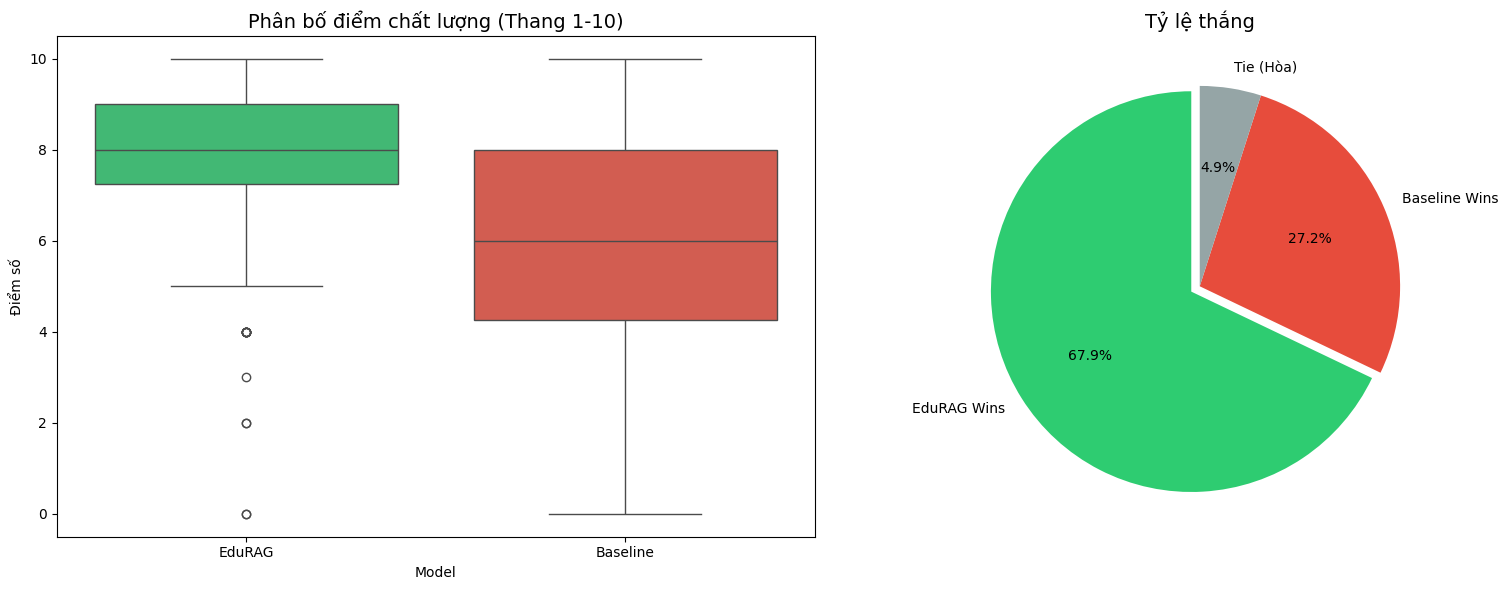

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: PHÂN BỐ ĐIỂM SỐ (Boxplot) ---
# Melt data để vẽ
df_scores = df_final[['score_rag', 'score_base']].melt(var_name='Model', value_name='Score')
df_scores['Model'] = df_scores['Model'].replace({'score_rag': 'EduRAG', 'score_base': 'Baseline'})

sns.boxplot(x='Model', y='Score', data=df_scores, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Phân bố điểm chất lượng (Thang 1-10)', fontsize=14)
axes[0].set_ylabel('Điểm số')

# --- BIỂU ĐỒ 2: TỶ LỆ THẮNG (Win Rate) ---
# Tính toán người thắng
def determine_winner(row):
    if row['score_rag'] > row['score_base']: return 'EduRAG Wins'
    elif row['score_rag'] < row['score_base']: return 'Baseline Wins'
    else: return 'Tie (Hòa)'

df_final['final_result'] = df_final.apply(determine_winner, axis=1)
win_counts = df_final['final_result'].value_counts()

axes[1].pie(win_counts, labels=win_counts.index, autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c', '#95a5a6'], startangle=90, explode=(0.05, 0, 0))
axes[1].set_title('Tỷ lệ thắng', fontsize=14)

plt.tight_layout()
plt.show()

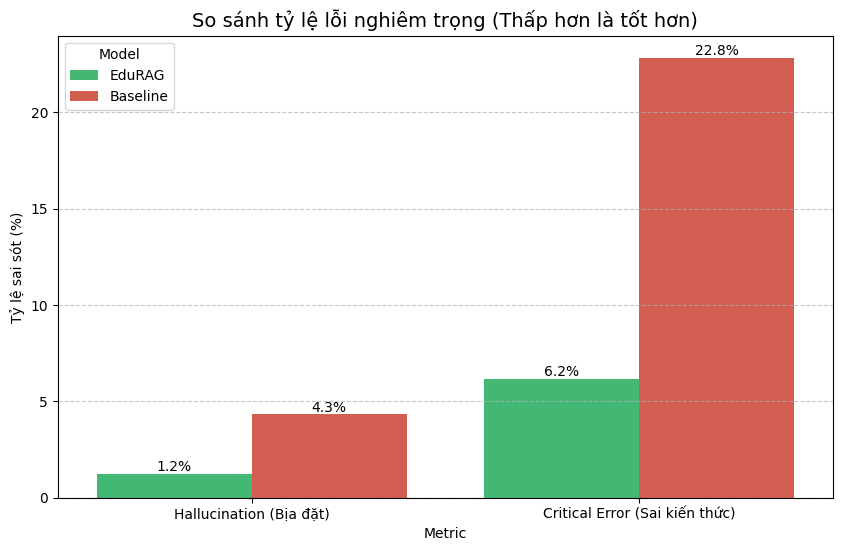

In [20]:
# Tính tỷ lệ lỗi
error_stats = pd.DataFrame({
    'Metric': ['Hallucination (Bịa đặt)', 'Critical Error (Sai kiến thức)'],
    'EduRAG': [
        df_final['rag_hallucination'].mean() * 100, 
        df_final['rag_critical_error'].mean() * 100
    ],
    'Baseline': [
        df_final['base_hallucination'].mean() * 100, 
        df_final['base_critical_error'].mean() * 100
    ]
})

# Melt để vẽ biểu đồ cột ghép
df_error_melt = error_stats.melt(id_vars='Metric', var_name='Model', value_name='Error Rate (%)')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Error Rate (%)', hue='Model', data=df_error_melt, palette=['#2ecc71', '#e74c3c'])

plt.title('So sánh tỷ lệ lỗi nghiêm trọng (Thấp hơn là tốt hơn)', fontsize=14)
plt.ylabel('Tỷ lệ sai sót (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm nhãn số liệu
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%')

plt.show()

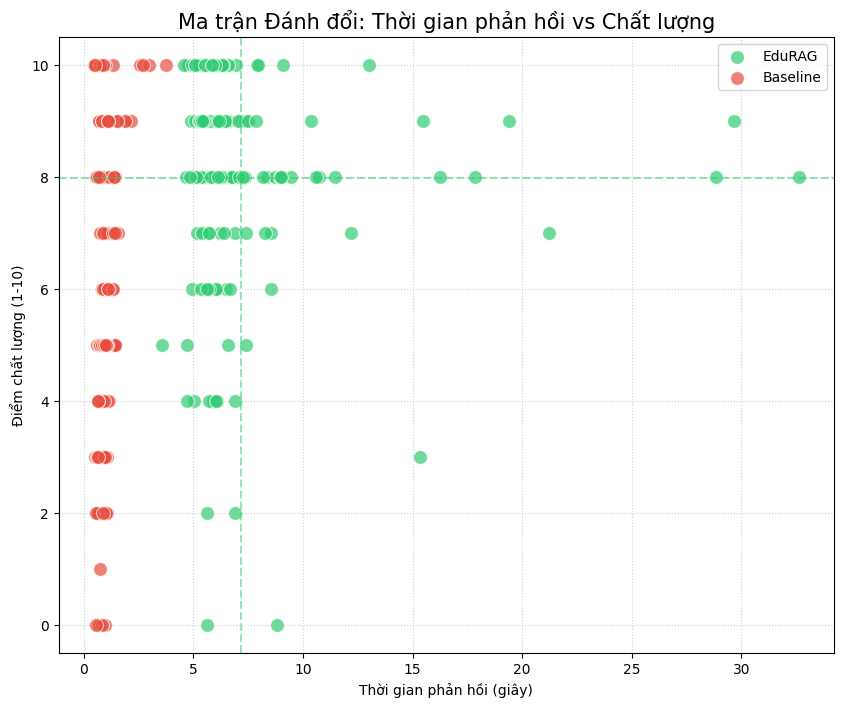

In [21]:
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=df_final, 
    x='edurag_time', y='score_rag', 
    color='#2ecc71', label='EduRAG', s=100, alpha=0.7
)
sns.scatterplot(
    data=df_final, 
    x='baseline_time', y='score_base', 
    color='#e74c3c', label='Baseline', s=100, alpha=0.7
)

# Vẽ đường trung bình
plt.axvline(df_final['edurag_time'].mean(), color='#2ecc71', linestyle='--', alpha=0.5)
plt.axhline(df_final['score_rag'].mean(), color='#2ecc71', linestyle='--', alpha=0.5)

plt.title('Ma trận Đánh đổi: Thời gian phản hồi vs Chất lượng', fontsize=15)
plt.xlabel('Thời gian phản hồi (giây)')
plt.ylabel('Điểm chất lượng (1-10)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [22]:
# --- TÍNH TOÁN CÁC CHỈ SỐ TRUNG BÌNH ---

# 1. Tính Delta (Chênh lệch) trung bình
avg_rag_time = df_final['edurag_time'].mean()
avg_base_time = df_final['baseline_time'].mean()
delta_time = avg_rag_time - avg_base_time # Thời gian chờ thêm (thường là số dương)

avg_rag_score = df_final['score_rag'].mean()
avg_base_score = df_final['score_base'].mean()
delta_score = avg_rag_score - avg_base_score # Điểm chất lượng tăng thêm

# 2. Tính Tỷ lệ đánh đổi (Efficiency Ratio)
# Công thức: Cần chờ bao nhiêu giây để tăng 1 điểm?
# Hoặc: 1 giây chờ đợi mang lại bao nhiêu điểm?
if delta_time > 0:
    points_per_second = delta_score / delta_time 
    seconds_per_point = delta_time / delta_score
else:
    points_per_second = 0 # Trường hợp hiếm: RAG nhanh hơn Base
    seconds_per_point = 0

# --- IN BÁO CÁO (TRADE-OFF REPORT) ---
print("="*50)
print("BÁO CÁO PHÂN TÍCH ĐÁNH ĐỔI (TIME vs QUALITY)")
print("="*50)

print(f"1. THỜI GIAN PHẢN HỒI TRUNG BÌNH:")
print(f"   - EduRAG:   {avg_rag_time:.2f}s")
print(f"   - Baseline: {avg_base_time:.2f}s")
print(f"   => EduRAG chậm hơn: {delta_time:.2f}s (+{(delta_time/avg_base_time)*100:.1f}%)")

print("-" * 30)

print(f"2. CHẤT LƯỢNG TRUNG BÌNH (THANG 10):")
print(f"   - EduRAG:   {avg_rag_score:.2f} điểm")
print(f"   - Baseline: {avg_base_score:.2f} điểm")
print(f"   => EduRAG tốt hơn:  {delta_score:.2f} điểm (+{(delta_score/avg_base_score)*100:.1f}%)")

print("-" * 30)

print(f"3. CHỈ SỐ HIỆU QUẢ (EFFICIENCY):")
if delta_score > 0 and delta_time > 0:
    print(f"   Người dùng chấp nhận chờ thêm {delta_time:.2f} giây.")
    print(f"   Đổi lại, chất lượng câu trả lời tăng {delta_score:.1f}% (trên thang 10).")
    print(f"   >>> KẾT LUẬN: Cứ mỗi {seconds_per_point:.2f} giây chờ đợi, chất lượng tăng thêm 1 điểm.")
elif delta_score <= 0:
    print("   >>> CẢNH BÁO: RAG không cải thiện chất lượng nhưng lại tốn thời gian hơn. Cần tối ưu lại.")
else:
    print("   >>> TUYỆT VỜI: RAG vừa nhanh hơn vừa tốt hơn (Trường hợp hiếm).")
print("="*50)

BÁO CÁO PHÂN TÍCH ĐÁNH ĐỔI (TIME vs QUALITY)
1. THỜI GIAN PHẢN HỒI TRUNG BÌNH:
   - EduRAG:   7.19s
   - Baseline: 0.99s
   => EduRAG chậm hơn: 6.20s (+628.2%)
------------------------------
2. CHẤT LƯỢNG TRUNG BÌNH (THANG 10):
   - EduRAG:   7.98 điểm
   - Baseline: 5.96 điểm
   => EduRAG tốt hơn:  2.02 điểm (+33.9%)
------------------------------
3. CHỈ SỐ HIỆU QUẢ (EFFICIENCY):
   Người dùng chấp nhận chờ thêm 6.20 giây.
   Đổi lại, chất lượng câu trả lời tăng 2.0% (trên thang 10).
   >>> KẾT LUẬN: Cứ mỗi 3.07 giây chờ đợi, chất lượng tăng thêm 1 điểm.


In [23]:
# Lọc ra các câu mà EduRAG 10 điểm, còn Baseline bị dính Hallucination
golden_cases = df_final[
    (df_final['score_rag'] >= 9) & 
    (df_final['base_hallucination'] == True)
]

if not golden_cases.empty:
    print(f"Tìm thấy {len(golden_cases)} trường hợp EduRAG sửa lỗi bịa đặt của Baseline.")
    
    # Lấy ví dụ đầu tiên
    case = golden_cases.iloc[0]
    print("\n--- VÍ DỤ ĐIỂN HÌNH ---")
    print(f"Câu hỏi: {case['question']}")
    print(f"\nEduRAG ({case['score_rag']}đ): {str(case['reason_rag'])}")
    print(f"Baseline ({case['score_base']}đ - BỊA ĐẶT): {str(case['reason_base'])}")
else:
    print("Không tìm thấy case nào quá đặc biệt theo tiêu chí này. Thử nới lỏng tiêu chí.")

Tìm thấy 4 trường hợp EduRAG sửa lỗi bịa đặt của Baseline.

--- VÍ DỤ ĐIỂN HÌNH ---
Câu hỏi: Hồ Chí Minh cho rằng, nếu không giữ đúng cần, kiệm, liêm, chính thì cán bộ, công chức dễ trở nên thế nào?

EduRAG (10.0đ): Bài làm A đã nêu đúng và đầy đủ quan điểm về việc cán bộ, công chức có thể trở nên hủ bại, biến thành sâu mọt của dân nếu không giữ đúng cần, kiệm, liêm, chính.
Baseline (5.0đ - BỊA ĐẶT): Bài làm B sử dụng những thuật ngữ như 'tham ô', 'lãng phí', 'quan liêu', nhưng không đúng với quan điểm của Hồ Chí Minh. Nội dung không hoàn toàn sai nhưng đã bịa đặt thông tin không có trong nguyên tác.


# ***Nhận xét***

Experimental results on the test dataset demonstrate that EduRAG delivers a significant improvement in response quality compared to the Baseline model. Specifically, the average quality score increased from 5.96 to 7.98 (corresponding to a 33.9% increase). This confirms the hypothesis that incorporating External Knowledge via RAG effectively overcomes the limitations regarding hallucinations and domain-specific knowledge deficiencies found in standard LLMs.

Regarding latency, EduRAG has an average response time of 7.19 seconds, compared to 0.99 seconds for the Baseline. However, this increase is both expected and acceptable. Trade-off Analysis indicates that for every additional 3.07 seconds of processing time, response quality improves by 1 point on a 10-point scale.

In the context of an educational support application for Political Theory subjects—where Correctness and Factuality are prioritized over real-time response speed—this trade-off is entirely worthwhile and necessary to ensure the system's pedagogical integrity.